## TP2 : Quadratic Assignment Problem

Imports

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import math
np.random.seed(32)

#### Part 1 : 29 september 2025

Our problem is the Quadratic Assignment Problem (QAP). It is a combinatorial optimization problem where we have to assign a set of facilities to a set of locations in such a way that the total cost is minimized. The cost is determined by the distances between locations and the flow between facilities.

**Cities and distances**

We will generate two problems of size 10 and 100.

In [16]:
# First, we initiate 12 cities with coordinates in a 100x100 grid.
# np.random.seed(42)

def generate_cities_random(num_cities,grid_size):
    """
    Generate num_cities in a grid of size grid_size x grid_size

    Parameters:
    num_cities (int) : the number of cities we want to generate
    grid_size (int) : the size of the grid

    Returns:
    coordinates (np.array(num_cities,2)) : Coordinates of the cities
    """
    coordinates = []
    generator = 0
    while generator < num_cities:
        value = np.random.randint(0, grid_size, size=(2,))
        # Check there's no city on the generated location
        if not any(np.array_equal(value, city) for city in coordinates):
            coordinates.append(value)
            generator += 1
    return np.array(coordinates)

def plot_cities(cities, facilities):
    """
    Generate random city coordinates within a grid.

    Parameters:
    cities (np.array(num_cities, 2): Coordinates of the cities.
    
    Returns:
    A scatter plot of the cities with their indices.
    """
    plt.figure(figsize=(6, 6))
    
    # Plot all cities
    plt.scatter(cities[:, 0], cities[:, 1], color='blue', s=50, label='City')
    
    # Annotate cities
    for i, (x, y) in enumerate(cities):
        plt.text(x - 3, y - 1, f'City {i}', fontsize=12, ha='right', color='blue')
    
    plt.scatter(
        cities[facilities, 0], cities[facilities, 1],
        facecolors='none', edgecolors='black', s=200, linewidths=2,
        label='Facility'
    )
    # Annotate facilities
    for j, idx in enumerate(facilities):
        x, y = cities[idx]
        plt.text(x + 1, y + 1, f'F{j}', fontsize=12, color='black', weight='bold')

    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.title('City Locations')
    plt.grid(True)
    plt.legend()
    plt.show()

In [17]:
def fitness(assignment, weights_matrix , distance_matrix):
    """
    Compute the fitness of an assignement of facilities to locations.

    Parameters:
    assignement (list of int): Permutation of size num_cities
    weights_matrix (np.array[num_cities][num_cities]) : Matrix of weights
    distance_matrix (np.array[num_cities][num_cities]) : Matrix of distances
    
    Returns:
    fitness (float) : The fitness of the assignement
    """
    fitness = 0.
    for i in range(len(assignment)):
        for j in range(len(assignment)):
            if i == j: continue
            fitness += weights_matrix[i, j] * distance_matrix[assignment[i], assignment[j]]
    return fitness

In [18]:
def generate_weights_random(num_cities, max_weight=25):
    """
    Generate a random weight matrix for the cities.

    Parameters:
    num_cities (int): Number of cities.
    max_weight (int): Maximum weight value.

    Returns:

    weights (np.array(num_cities, num_cities)): Weight matrix.
    """
    weights = np.random.randint(0, max_weight, size=(num_cities, num_cities))*(np.ones((num_cities, num_cities)) - np.eye(num_cities))
    weights = ((weights + weights.T) / 2).astype(int)
    assert np.max(weights) < max_weight, f"Max must be less than {max_weight} !"
    return weights

def compute_distance_matrix(cities):
    """
    Compute the distance matrix between cities.

    Parameters:
    cities (np.array(num_cities, 2)): Coordinates of the cities.

    Returns:
    distance_matrix (np.array(num_cities, num_cities)): Distance matrix.
    """
    d = lambda x, y: np.sqrt((y[0] - x[0])**2 + (y[1] - x[1])**2)
    distance_matrix = np.zeros((cities.shape[0], cities.shape[0]))
    for i in range(len(cities)):
        for j in range(len(cities)):
            if i != j:
                distance_matrix[i, j] = d(cities[i], cities[j])
    assert np.array_equal(distance_matrix, distance_matrix.T), "Distance matrix must be symetric !"
    return distance_matrix

### Greedy easy method 

In [19]:
def greedy_easy(weights, distance_matrix):
    """
    Greedy heuristic for the Quadratic Assignment Problem:
    facilities with highest total weight -> locations with lowest total distance.
    """
    n = weights.shape[0]

    # Sum of the weights (decreasing order)
    w_sum = np.array(np.sum(weights, axis=1))
    w_sort = (np.argsort(-w_sum, stable=True))


    # Sum of distances for each city (ascending order)
    d_sum = np.sum(distance_matrix, axis=1)
    d_sort = np.argsort(d_sum, stable=True)
    

    assignment = np.zeros(n, dtype=int)
    for i in range(n):
        assignment[w_sort[i]] = d_sort[i]

    fitness_greedy = fitness(assignment, weights, distance_matrix)

    return assignment.tolist(), fitness_greedy

### Greedy solution (other method)

In [20]:
def get_best_neighbour(city1, neighbour_dict, free_list):
    # Returns the best free location at the minimum distance from city1
    for city2 in neighbour_dict[city1]:
        if free_list[city2]:
            return city2
    return None

def get_two_good_places(emp1_list, emp2_list, free_list):
    # Returns two free locations that are at minimal distance from each other
    for e1, e2 in zip(emp1_list, emp2_list):
        if e1 != e2 and free_list[e1] and free_list[e2]:
            return e1, e2
    return None, None

def greedy_solution(weights, distance_matrix):
    n = weights.shape[0]
    assignment = {}

    # Distances sorted (only pairs where i < j are considered)
    idx_distance = np.argsort(distance_matrix, axis=None, stable=True)
    rows_d, cols_d = np.unravel_index(idx_distance, distance_matrix.shape)

    best_neighbour = {}
    for i, j in zip(rows_d, cols_d):
        if i != j:
            best_neighbour.setdefault(i, []).append(j)

    # Sort the flows in decreasing order (strongest connections first)
    # (Sort the weights of the W matrix)
    idx_weights = np.argsort(weights, axis=None, stable=True)[::-1]
    rows_w, cols_w = np.unravel_index(idx_weights, weights.shape)
    
    covered = np.zeros(n, dtype=bool)
    free_pos = np.ones(n, dtype=bool)

    # Browse the links in decreasing order of weight
    for c1, c2 in zip(rows_w, cols_w):
        if c1 == c2:
            continue
        # If a link involves two cities that have not been placed yet
        if not covered[c1] and not covered[c2]:
            # Find the best positions for both cities (minimum distance)
            e1, e2 = get_two_good_places(rows_d, cols_d, free_pos)
            if e1 is None:
                break
            assignment[c1], assignment[c2] = e1, e2
            covered[c1], covered[c2] = True, True
            free_pos[e1], free_pos[e2] = False, False
        # If only one of the two cities has already been placed
        elif not covered[c1]:
            # Find the best possible neighbor location for the already placed city (minimum distance)
            e1 = get_best_neighbour(assignment.get(c2, c2), best_neighbour, free_pos)
            if e1 is not None:
                assignment[c1] = e1
                covered[c1] = True
                free_pos[e1] = False

        elif not covered[c2]:
            # Same as above but for the second city
            e2 = get_best_neighbour(assignment.get(c1, c1), best_neighbour, free_pos)
            if e2 is not None:
                assignment[c2] = e2
                covered[c2] = True
                free_pos[e2] = False

    return assignment, fitness(assignment, weights, distance_matrix)


Can you try to understand how the two greedy algorithms work ?

- Greedy easy

- Greedy_solution

#### Greedy easy

This implementation give a solution by taking the sum of all weight and distances for each cities, and then attribute a facilitie for each city with this caracteristics: we take the facility which is the most "weight" overall and then we attribute to this the city that has less distance overall.

So it means that our greedy solution give a minimum of distance to travel when the weight of the facility is big.

#### Greedy solution

In this more complex implementation, we take the more weight facilitie connection, and then we place on the minimum distance between cities. Then, for the next, if one of the two facilities is already placed, we check neighbors to find the nearest neighbor where no facility is placed. We make it for each binom of facilities.

### Setting of a problem for 12 cities

In [21]:
positions = np.array([[ 25.00616036,   5.37921308],
       [ 49.37825796,  16.97220412],
       [ 75.12183688,  28.52093225],
       [100.        ,  39.08588089],
       [ 13.01467739,  33.39197468],
       [ 37.35707173,  44.41047962],
       [ 62.58758625,  55.73908367],
       [ 87.02189107,  66.60010608],
       [  0.        ,  60.87168438],
       [ 24.86845828,  71.56597651],
       [ 50.62776159,  83.13474908],
       [ 75.23837967,  94.54979682]], dtype=float)

D = np.array([
    [0,1,2,3,1,2,3,4,2,3,4,5],
    [1,0,1,2,2,1,2,3,3,2,3,4],
    [2,1,0,1,3,2,1,2,4,3,2,3],
    [3,2,1,0,4,3,2,1,5,4,3,2],
    [1,2,3,4,0,1,2,3,1,2,3,4],
    [2,1,2,3,1,0,1,2,2,1,2,3],
    [3,2,1,2,2,1,0,1,3,2,1,2],
    [4,3,2,1,3,2,1,0,4,3,2,1],
    [2,3,4,5,1,2,3,4,0,1,2,3],
    [3,2,3,4,2,1,2,3,1,0,1,2],
    [4,3,2,3,3,2,1,2,2,1,0,1],
    [5,4,3,2,4,3,2,1,3,2,1,0]
], dtype=int)


W = np.array([[ 0,  5,  2,  4,  1,  0,  0,  6,  2,  1,  1,  1],
        [ 5,  0,  3,  0,  2,  2,  2,  0,  4,  5,  0,  0],
        [ 2,  3,  0,  0,  0,  0,  0,  5,  5,  2,  2,  2],
        [ 4,  0,  0,  0,  5,  2,  2, 10,  0,  0,  5,  5],
        [ 1,  2,  0,  5,  0, 10,  0,  0,  0,  5,  1,  1],
        [ 0,  2,  0,  2, 10,  0,  5,  1,  1,  5,  4,  0],
        [ 0,  2,  0,  2,  0,  5,  0, 10,  5,  2,  3,  3],
        [ 6,  0,  5, 10,  0,  1, 10,  0,  0,  0,  5,  0],
        [ 2,  4,  5,  0,  0,  1,  5,  0,  0,  0, 10, 10],
        [ 1,  5,  2,  0,  5,  5,  2,  0,  0,  0,  5,  0],
        [ 1,  0,  2,  5,  1,  4,  3,  5, 10,  5,  0,  2],
        [ 1,  0,  2,  5,  1,  0,  3,  0, 10,  0,  2,  0]])


## Compare the performance of the two greedy algorithms :

- First, generate a problem with random weights for 12 cities on a 100x100 grid. Generate a thousand permutations of facilities and compute the average mean value of the fitness of such permutations. Compare the value with the two greedy algorithm. How much better do they perform ?

- Now, same task with the weights just above. Plot the repartition of the cities and the assignement of the facilities for the two greedy algorithms.

#### Here we generate a random problem for 12 cities

Relative distance random fitness to easy greedy fitness for random : 6349.240839261358
Relative distance random fitness to solution_greedy for random : 5428.937552282412
Difference between greedy_easy and greedy_solution: -920.3032869789458


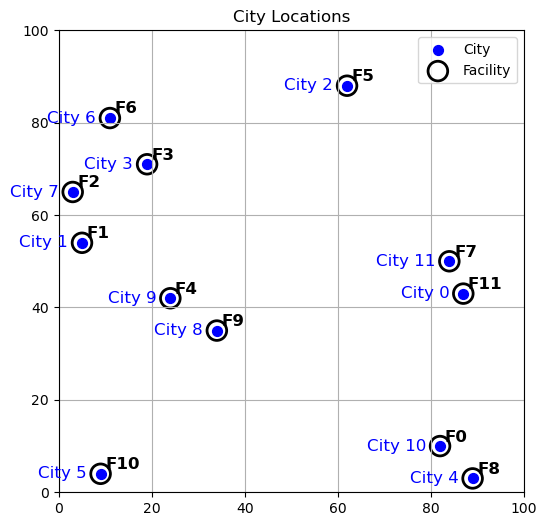

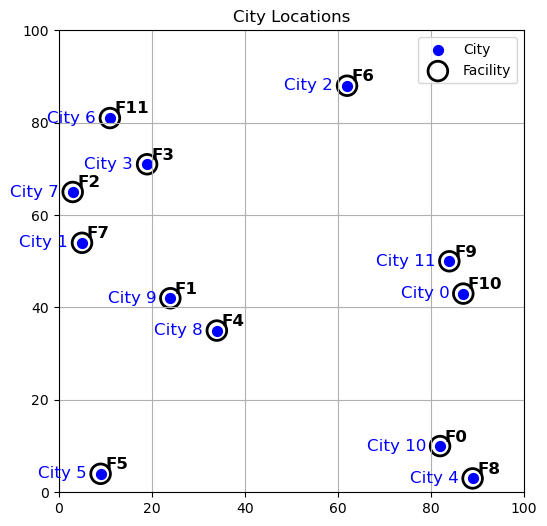

In [22]:
cities_positions_12 = generate_cities_random(12,100)
distances_12 = compute_distance_matrix(cities_positions_12)
weights_12 = generate_weights_random(12,25)

def average_mean_value(weights: np.ndarray, distances: np.ndarray) -> float:
    permutations = np.arange(12)
    fitness_random = 0
    for i in range(1000):
        np.random.shuffle(permutations)
        fitness_random += fitness(permutations, weights, distances)
    return fitness_random / 1000

fitness_random_12 = average_mean_value(weights_12, distances_12)
assignment_easy_12, fitness_greedy_easy_12 = greedy_easy(weights_12, distances_12)
assignment_solution_12, fitness_greedy_solution_12 = greedy_solution(weights_12, distances_12)
print('Relative distance random fitness to easy greedy fitness for random : {}'.format(np.abs(fitness_greedy_easy_12 - fitness_random_12)))
print('Relative distance random fitness to solution_greedy for random : {}'.format(np.abs(fitness_greedy_solution_12 - fitness_random_12)))
print(f'Difference between greedy_easy and greedy_solution: {fitness_greedy_easy_12 - fitness_greedy_solution_12}')

plot_cities(cities_positions_12, assignment_easy_12)
assignment_solution_12 = [assignment_solution_12[i] for i in range(12)]
plot_cities(cities_positions_12, assignment_solution_12)

#### Observations

We can see that the difference between the average of fitness and the greedy methods is always very different because we have always big differences between 100 and 10000.

However, we can constate that the variance of difference is big, due to values generated randomly.

Another thing that we can see if we execute multiple time the python cell is that the `greedy_solution` algorithm give in most of times a better solution than the `greedy_easy` algorithm.

So we can conclude than results of greedy methods are better than result obtained by the mean of the values.

And we can also conclude that empiricaly, the `greedy_solution` seems to be better than the `greedy_easy` solution, which is due to more precise work with more complex algorithm, I think...

#### Here we compute the fitness of the greedy algorithms and compare it to the random permutationsfor the given problem

Relative distance random fitness to easy greedy fitness for random : 65.06399999999996
Relative distance random fitness to solution_greedy for random : 113.06399999999996
Difference between greedy_easy and greedy_solution: 48.0


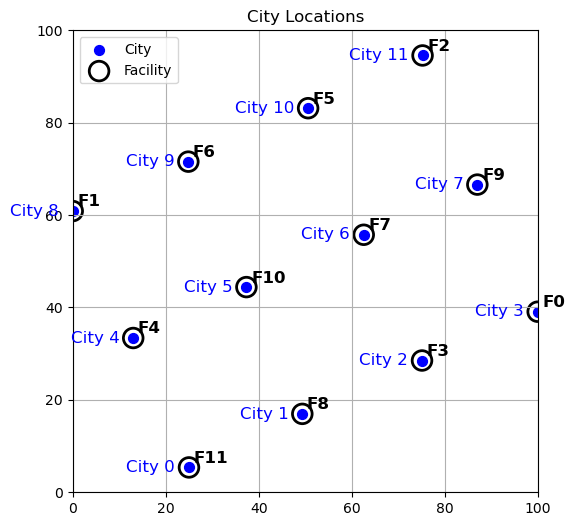

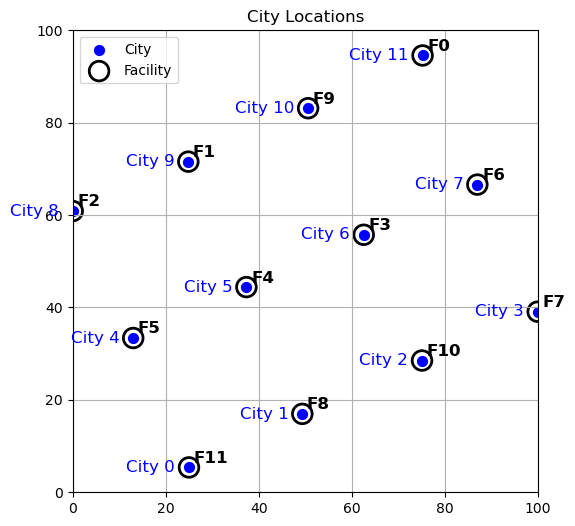

In [23]:
fitness_random_problem = average_mean_value(W, D)
assignment_easy_problem, fitness_greedy_easy_problem = greedy_easy(W, D)
assignment_solution_problem, fitness_greedy_solution_problem = greedy_solution(W, D)
print('Relative distance random fitness to easy greedy fitness for random : {}'.format(np.abs(fitness_random_problem - fitness_greedy_easy_problem)))
print('Relative distance random fitness to solution_greedy for random : {}'.format(np.abs(fitness_random_problem - fitness_greedy_solution_problem)))
print(f'Difference between greedy_easy and greedy_solution: {fitness_greedy_easy_problem - fitness_greedy_solution_problem}')

plot_cities(positions, assignment_easy_problem)
assignment_solution_problem = [assignment_solution_problem[i] for i in range(12)]
plot_cities(positions, assignment_solution_problem)

### Observations

We can constate that we don't have a huge difference between the random method and greedy methods like with generated values.
In fact, we can constate that the city are well distributed in our space, like shown in graphics.
So due to the structure of the datas, the random method give results that becomes closest to greedy results.
Or perhaps we can see this in another way: all the cities seems to be at equidistance, so greedy methods have difficulties to make choices to place correctly the facilities that's why the average made on multiple iteration is closer greedy methods...

In fact, greedy methods can give good results when datas are generated randomly, but perhaps greedy methods can aslo give bad results, a little in the same way when working with a function, the method could stay blocked in a minimum local...
And I think that executing the code multiple times give always huge difference between `greedy_easy` and `greedy_solution` because of this reason...
It's a little like if random generated datas give random results, but a little better when using greedy methods...

When we look at the difference between fitness of `greedy_easy` and fitness of `greedy_solution` method, we can see that one more time the `greedy_solution` gives a better result than the `greedy_easy` because the fitness is more minimised.

### Optionnal

Try to think of a better way of generating cities and weights.

What could you do to try to have something better when generating a problem ?

When we look at the random generated values, the cities are not distributed in the entire space, but only a part of the space is used.
And on top of that, the variance of the distance between the cities is in most of cases huge.

So I think that a better way of generating cities and weights could be perhaps to well distributate the cities in space, or simply put a range of distance.
If we distribute well the cities in our space, I think that the variance of the distance will decrease.
And putting a range on distance will make a more good city repartition in the space.
However, putting a range on distances allows us to be closer to the reality.
For instance, we can have a distance that is minimum 20 KM between cities and maximum 100KM in a specific part of land.
So with cities placed randomly, our simulation of the reality will not respect this constraints and be more far of the reality.
That's why we try to add a notion of range of distance in the genrate cities better...
However, as a compagny can have multiple facilities that have totaly different weight, I think it's not a good idea to restrict the weight of the facilities.
We can perhaps adding a condition on the lowest value, that make sense.

When we look at results (that can be in standby due to the code that didn't find element that match conditions), we see that it looks more to a real case with a set of cities on a map... We can play on parameters to have more or less distance between cities.
And we can play with parameters to have also more well distributed cities in our space.

In [24]:
def generate_cities_better(num_cities, grid_size=100, distance_range: tuple[int] = (15, 60)):
    """
    Generate better city coordinates within a grid.

    Parameters:
    num_cities (int): Number of cities to generate.
    grid_size (int): Size of the grid (grid_size x grid_size).

    Returns:
    cities_coordinates : Array of shape (num_cities, 2) with city coordinates.
    """
    def check_distance(city, list_cities, distance_range = distance_range) -> bool:
        if len(list_cities) == 0: return True
        d = lambda x, y: np.sqrt((y[0] - x[0])**2 + (y[1] - x[1])**2)
        distances = [d(city, i) for i in list_cities]
        if np.max(distances) <= distance_range[1] and np.min(distances) >= distance_range[0]:
            return True
        return False
    coordinates = []
    generator = 0
    while generator < num_cities:
        value = np.random.randint(0, grid_size, size=(2,))
        # Check there's no city on the generated location
        if not any(np.array_equal(value, city) for city in coordinates) and check_distance(value, coordinates):
            coordinates.append(value)
            generator += 1
    return np.array(coordinates)


def generate_weights_better(num_cities, min_weight=5, max_weight=25):
    """
    Generate a better weight matrix for the cities.

    Parameters:
    num_cities (int): Number of cities.
    max_weight (int): Maximum weight value.

    Returns:

    weights (np.array(num_cities, num_cities)): Weight matrix.
    """
    weights = np.random.randint(low=min_weight, high=max_weight, size=(num_cities, num_cities))*(np.ones((num_cities, num_cities)) - np.eye(num_cities))
    weights = ((weights + weights.T) / 2).astype(int)
    assert np.max(weights) < max_weight, f"Max must be less than {max_weight} !"
    return weights

Relative distance random fitness to easy greedy fitness for random : 2370.506746948682
Relative distance random fitness to solution_greedy for random : 663.2883556940214
Difference between greedy_easy and greedy_solution: 3033.7951026427036


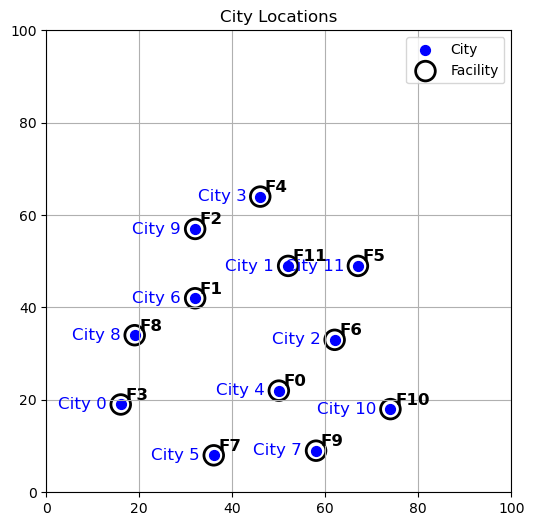

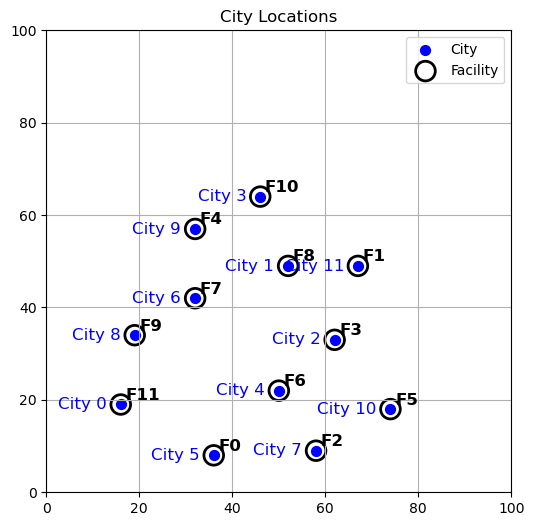

In [25]:
cities_12_better = generate_cities_better(12,100)
cities_distances_12_better = compute_distance_matrix(cities_12_better)
weights_12_better = generate_weights_better(12,5,25)
assignement_12_easy_better, fitness_easy_greedy_12_better = greedy_easy(weights_12_better, cities_distances_12_better)
assignement_12_solution_better, fitness_solution_greedy_12_better = greedy_solution(weights_12_better, cities_distances_12_better)
fitness_random_12_better = average_mean_value(weights_12_better, cities_distances_12_better)
print('Relative distance random fitness to easy greedy fitness for random : {}'.format(np.abs(fitness_easy_greedy_12_better - fitness_random_12_better)))
print('Relative distance random fitness to solution_greedy for random : {}'.format(np.abs(fitness_solution_greedy_12_better - fitness_random_12_better)))
print(f'Difference between greedy_easy and greedy_solution: {fitness_solution_greedy_12_better - fitness_easy_greedy_12_better}')

plot_cities(cities_12_better, assignement_12_easy_better)
assignement_12_solution_better= [assignement_12_solution_better[i] for i in range(12)]
plot_cities(cities_12_better, assignement_12_solution_better)

### Part 2: So now we can try to implement the tabu search

We are going to test the tabu search for the given problem and see if :
- the performance is better than the greedy algorithms ?
- how many iterations are required to get a better result ?
- test the stability of the solutions when we add some noise ?

In [71]:
# ================================================================
# Tabu Search with optional Diversification
# ================================================================
# Skeleton for implementing the Tabu Search algorithm
# to solve the Quadratic Assignment Problem (QAP).
# Fill in each function with your own logic.
# ================================================================

def swap(permutation, i, j):
    """
    Return a new permutation where the elements at indices i and j are swapped.

    Parameters:
    permutation (list or np.ndarray): Current assignment.
    i, j (int): Indices to swap.

    Returns:
    (list or np.ndarray): New permutation with i and j exchanged.
    """
    # create a copy or modify in place to swap positions i and j
    swap_permutation = permutation.copy()
    swap_permutation[i], swap_permutation[j] = swap_permutation[j], swap_permutation[i]
    return swap_permutation


def delta_i_j(permutation, i, j, weights, distance):
    """
    Compute the change in objective value if we swap facilities i and j.

    Parameters:
    permutation (list or np.ndarray): Current assignment.
    i, j (int): Indices of facilities to swap.
    weights (np.ndarray): Flow matrix.
    distance (np.ndarray): Distance matrix.

    Returns:
    float: Change in cost after swapping i and j.
    """
    # compute the fitness difference directly or with the O(n) delta formula
    return fitness(swap(permutation, i, j), weights, distance) - fitness(permutation, weights, distance)


def best_swap(weights, distance, permutation, current_fitness, best_fitness, tabu_matrix, itr):
    """
    Identify the best neighbor of the current solution
    while respecting Tabu Search rules.
    
    Parameters:
    weights (np.ndarray) : Flow matrix of the QAP.
    distance (np.ndarray) : Distance matrix of the QAP.
    permutation (list or np.ndarray) : Current assignment of facilities to locations.
    current_fitness (float) : Cost of the current solution.
    best_fitness (float) : Best cost found so far (global best).
    tabu_matrix (np.ndarray) : Matrix that stores, for each possible swap, the iteration number until which it is tabu.
    itr (int) : Current iteration index.

    Returns:
    i, j (int): Indices of the selected swap.
    delta (float): Change in cost for the swap.
    is_best (bool): True if this move improves the global best solution.
    """
    delta = []
    # iterate over all pairs (i, j)
    for i in range(len(permutation)):
        for j in range(len(permutation)):
            if i == j: continue
            # skip tabu moves unless aspiration criterion is met
            if tabu_matrix[i, j] > itr: continue
            # compute delta for each swap
            delta.append((i, j, delta_i_j(permutation, i, j, weights, distance)))
    delta = np.array(delta)
    # keep track of the best candidate
    minimum = delta[delta[:, 2] == np.min(delta[:, 2])].astype(int)
    assert len(minimum.shape) == 2, "The output of the previous operation give a 2D array !"
    randomSwap = np.random.randint(0, minimum.shape[0])
    i, j, max_delta = minimum[randomSwap]
    return i, j, max_delta, max_delta < 0


def tabu_search(weights, distance, tabu_tenure, tmax, diversification: bool = False, u: int = 100):
    """
    Main Tabu Search routine.
    Parameters:
    weights (np.ndarray): Flow between locations.
    distance (np.ndarray): Distance between locations.
    tabu_tenure (int): Number of iterations a move remains tabu.
    tmax (int): Total number of iterations.
    diversification (bool): Enable diversification strategy.
    u (int): Number of iterations after which diversification triggers.

    Returns:        
    best_fitness (float): Best objective value found.
    best_permutation (list or np.ndarray): Best assignment found.
    fitness_history (list): Cost of each visited solution.
    best_history (list): Best cost at each iteration.
    """
    # initialize permutation and tabu matrix
    permutation = np.random.permutation(distance.shape[0])
    # check distance matrix is squared
    assert distance.shape[0] == distance.shape[1], "Distance matrix must be square"
    tabu_matrix = np.zeros_like(distance)
    # initialize diversification structures if enabled

    current_fitness = fitness(permutation, weights, distance)
    best_fitness = current_fitness
    best_permutation = permutation
    fitness_history = [best_fitness]
    best_history = [best_fitness]
    # repeat for tmax iterations:
    for k in range(tmax):
        #   choose move (best swap or diversification)
        if diversification:
            # Get iteration number since last trigger of all permutations
            diversification_matrix = k - tabu_matrix
            # Get index of all elements that need to be triggered
            index_matrix = np.argwhere(diversification_matrix >= u)
            # If index is null, take best_swap
            if index_matrix.shape[0] == 0:
                i, j, delta, is_best = best_swap(weights, distance, permutation, current_fitness, best_fitness, tabu_matrix, k)
            # Else take random element that needs to be triggered
            else:
                randomvalue = np.random.randint(0, index_matrix.shape[0])
                i, j = index_matrix[randomvalue]
                delta = delta_i_j(permutation, i, j, weights, distance)
        else:
            i, j, delta, is_best = best_swap(weights, distance, permutation, current_fitness, best_fitness, tabu_matrix, k)
        #   apply move and update current fitness
        permutation = swap(permutation, i, j)
        current_fitness += delta
        fitness_history.append(current_fitness)
        #   update best solution if improved
        if current_fitness < best_fitness:
            best_fitness = current_fitness
            best_permutation = permutation
        best_history.append(best_fitness)
        #   update tabu matrix
        tabu_matrix[i, j] = k + tabu_tenure
        tabu_matrix[j, i] = k + tabu_tenure
        #   update diversification bookkeeping if enabled

    # return final best solution and histories
    return best_fitness, best_permutation, np.array(fitness_history), np.array(best_history) 

# ------------------------------------------------
# Diversification:
# implement a mechanism that forces rarely-used
# swaps to be tried after u iterations
# ------------------------------------------------


Best fitness: 586.0
Best permutation: [ 2  1  3  9  8  4  6 10  7  0  5 11]


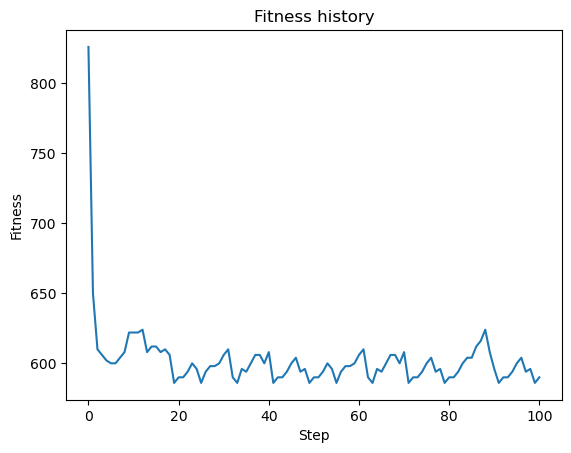

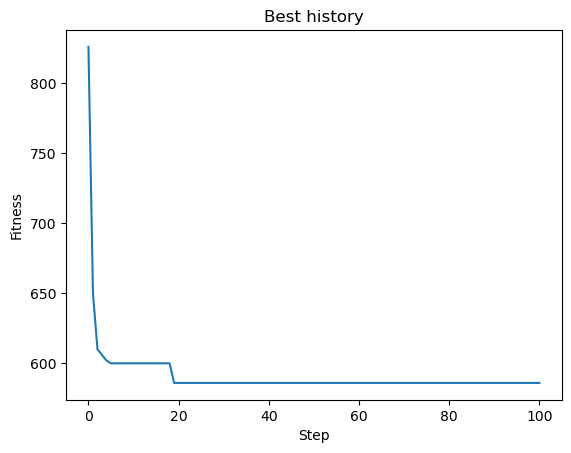

In [72]:
best_fitness, best_permutation, fitness_history, best_history = tabu_search(W, D, 4, 100)
print(f"Best fitness: {best_fitness}")
print(f"Best permutation: {best_permutation}")
plt.figure()
plt.plot(np.arange(len(fitness_history)), fitness_history)
plt.title("Fitness history")
plt.xlabel("Step")
plt.ylabel("Fitness")
plt.show()
plt.figure()
plt.plot(np.arange(len(best_history)), best_history)
plt.title("Best history")
plt.xlabel("Step")
plt.ylabel("Fitness")
plt.show()

We can see here that we converge fastly to a good solution.

We can constate that from step 20 to step 100, we are always oscilating around a fitness of 600.
It means that the method will stop not when the method has found a good solution, but only when the correct number of iteration is reached.

So if we don't optimize the number of iterations, we can fastly make the algorithm running with no improvement of the solution.
For instance, in our case, only 20 iterations are needed to have good results...
The next iterations don't add any improvement to the result.
So we must right balance the guided parameters with the searched soluce and the cost of the search in term of CPU, ...

Best fitness (with diversification = 40): 586.0
Best permutation (with diversification): [10  9 11  1  0  4  6  2  7  8  5  3]


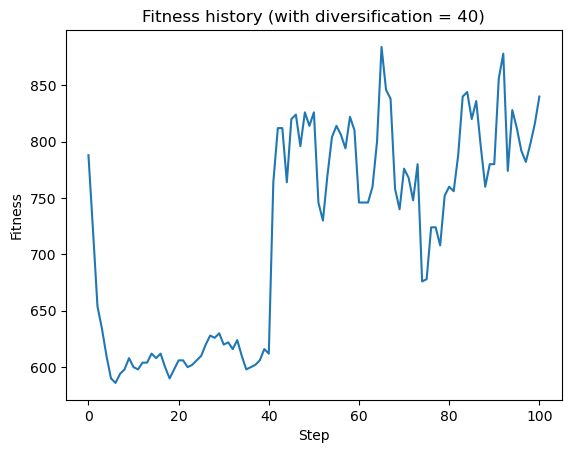

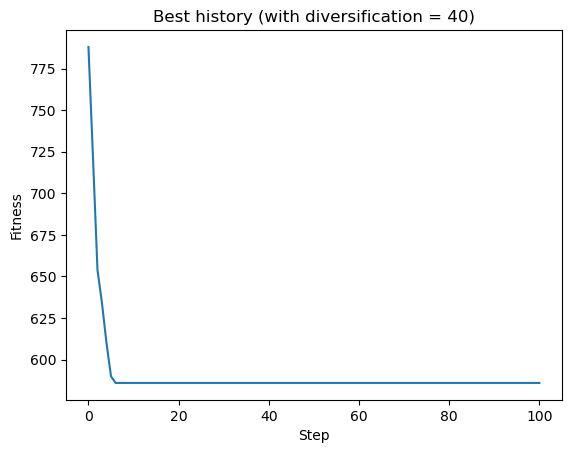

In [74]:
best_fitness, best_permutation, fitness_history, best_history = tabu_search(W, D, 4, 100, True, 40)
print(f"Best fitness (with diversification = 40): {best_fitness}")
print(f"Best permutation (with diversification): {best_permutation}")
plt.figure()
plt.plot(np.arange(len(fitness_history)), fitness_history)
plt.title("Fitness history (with diversification = 40)")
plt.xlabel("Step")
plt.ylabel("Fitness")
plt.show()
plt.figure()
plt.plot(np.arange(len(best_history)), best_history)
plt.title("Best history (with diversification = 40)")
plt.xlabel("Step")
plt.ylabel("Fitness")
plt.show()

We can see here in the fitness history that with diversification that force to use not used solution, when we go up to the diversification limit, the fitness increase a lot.
It's due to the obligatory choice of a permutation that is perhaps not better than the other choices we made precedently because this solution was never choosed.

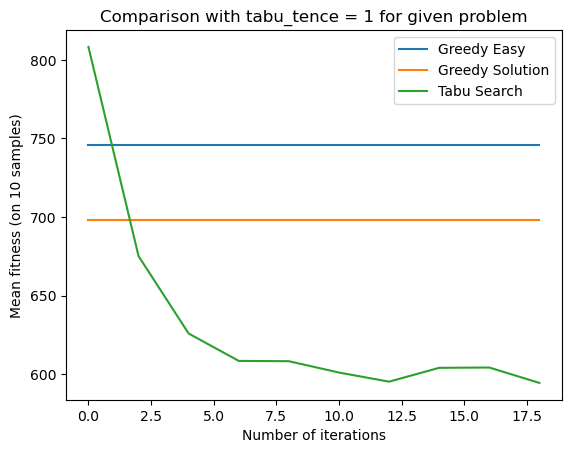

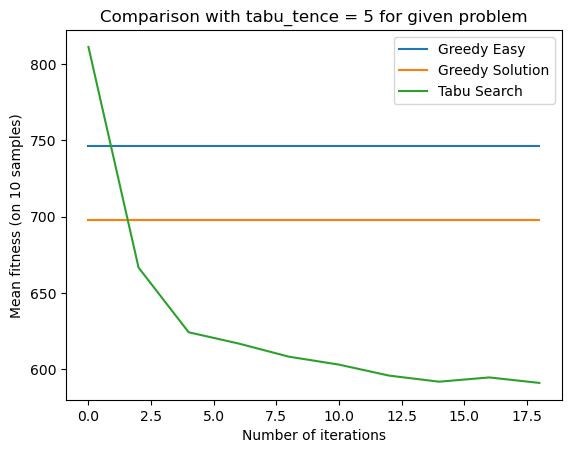

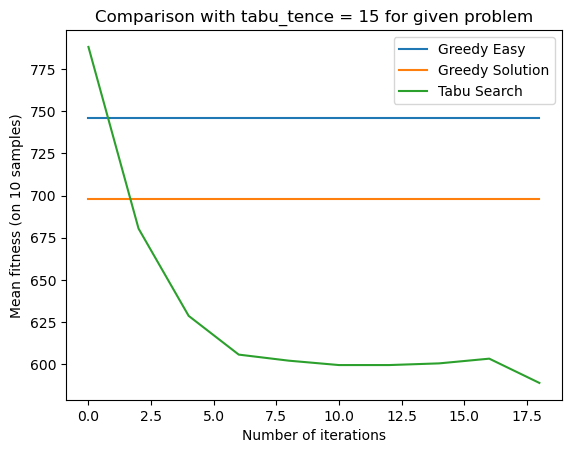

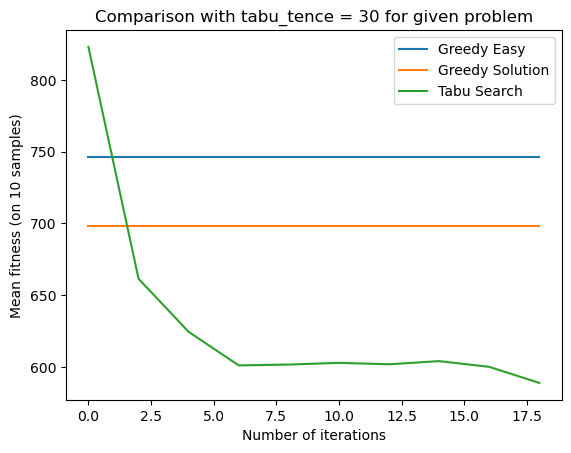

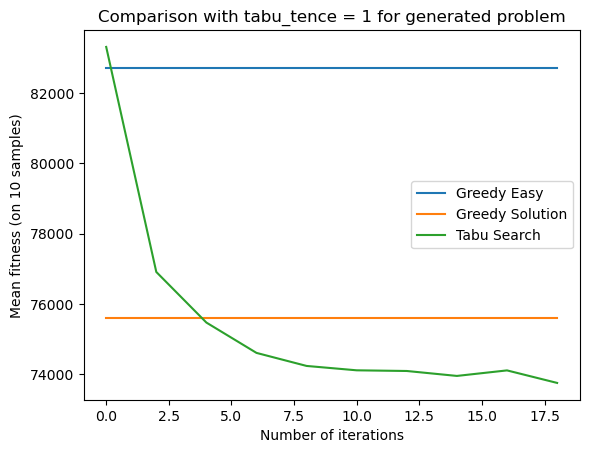

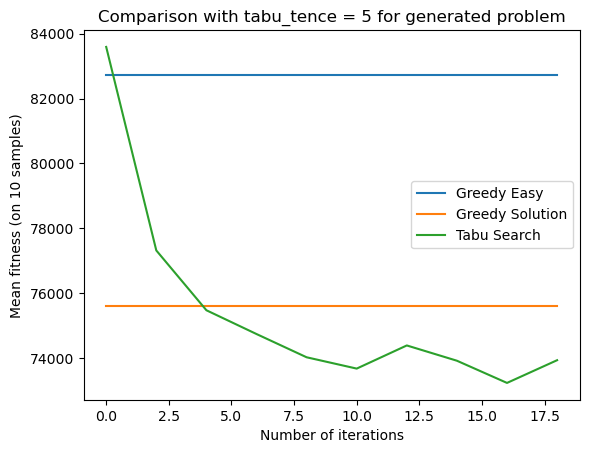

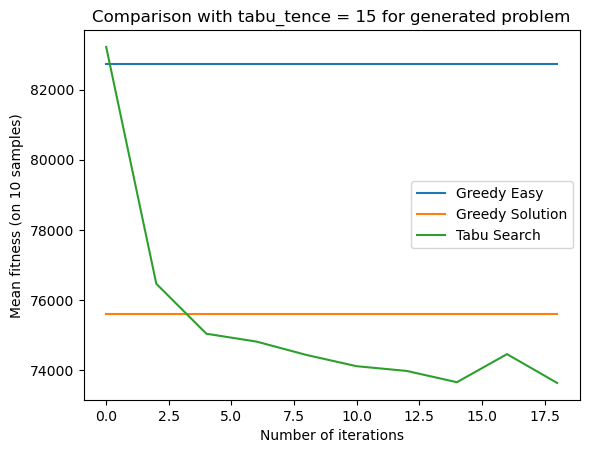

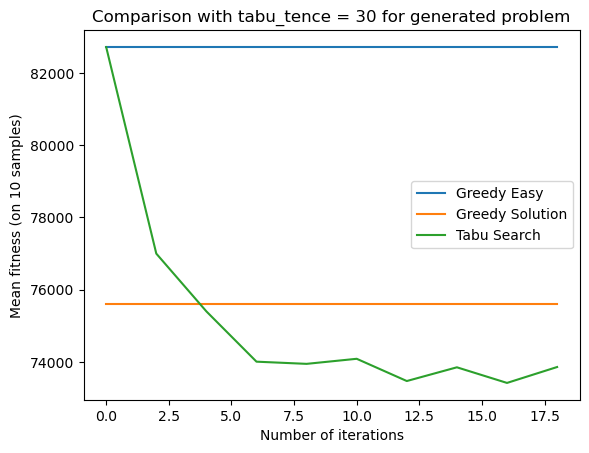

In [ ]:
def plot_difference(W, D, problem_type: str = "given"):
    assignment_easy_problem, fitness_greedy_easy_problem = greedy_easy(W, D)
    assignment_solution_problem, fitness_greedy_solution_problem = greedy_solution(W, D)

    for i in [1, 5, 15, 30]:
        tabu_solution = []
        x = np.arange(0, 20, 2)
        for j in x:
            mean = []
            for k in range(10):
                best_fitness, best_permutation, fitness_history, best_history = tabu_search(W, D, i, j)
                mean.append(tabu_search(W, D, i, j)[0])
            tabu_solution.append(np.mean(mean))

        plt.figure()
        plt.title(f"Comparison with tabu_tenure = {i} for {problem_type} problem")
        plt.plot(x, fitness_greedy_easy_problem * np.ones_like(x), label="Greedy Easy")
        plt.plot(x, fitness_greedy_solution_problem * np.ones_like(x), label="Greedy Solution")
        plt.plot(x, tabu_solution, label="Tabu Search")
        plt.xlabel("Number of iterations")
        plt.ylabel("Mean fitness (on 10 samples)")
        plt.legend()
        plt.show()
plot_difference(W, D)
cities_positions = generate_cities_random(12,100)
distances = compute_distance_matrix(cities_positions_12)
weights = generate_weights_random(12,25)
plot_difference(weights, distances, "generated")

In the graph, I have made the plot of the greedy solution, easy and tabu search methods on the given problem and on a generated problem.

The number of iterations give the max number of iterations for the tabu search.

The fitness curve of the tabu search is obtained by making the mean of 10 executions of the method for the given guided parameters.

So we can see that the performances are better than the greedy algorithm because we find better fitness than the greedy algorithm.

It means that the "tabu search" search in the right direction and give fastly a soluce, like the decreasing curves show us. The soluce found is perhaps not optimal, but better than greedy algorithm soluce.

If we add some noise in the data, the tabu search will be relatively stable depending on the given parameters, as the max number of iterations and the tenure because the tenure will force the exploration of new nodes by excluding already visited nodes from the neighbourhood.
The end of the exploration is given by the maximum number of iterations, so unlike the greedy methods, we will not be blocked in a local solution (always depending on the guided parameters maximum number of iterations and tenure of tabu search !). However, we will spend more time to find it because when we find the optimal solution, we will continue to search to find another optimal solution better than the finded solution.

And we can constate it when looking at the graphics for generated problem: the shapes of tabu search are always approximatively the same, but with a 100 factor (we are working on fitness of $O(10000)$ instead of $O(100)$). So it means that the method is approximatively stable depending on parameters.

## What is the size of a neighbourhood ?

A neighbourhood is given by all the permutation of two elements of the list of cities, excluding the permutations not authorised that are present in the tabu list.

We must be careful to don't include two times the same permutation.

So we can write the number of permutations for a problem of size $n$ (with permutation of only 2 elements) like this:

$$\begin{pmatrix}n \\ 2 \end{pmatrix} = \frac{n (n - 1)}{2}$$

So for 12 cities, the maximal number of permutations is

$$\dfrac{12(12 - 1)}{2} = 66$$

So for 12 cities, each node to visit has a neighboorhood of maximum $66$ neighbors minus all excluded neighbors from tabu list.

The permutations of the tabu list are present in the tabu list only for a number of iterations given by `tabu_tenure` parameter.

A permutation becomes tabu when it is used: we don't want to revisit a soluce already visited until the iteration given by `"current iteration" + tabu_tenure`

## Optionnal : can you think of en efficient way of implementing the diversification ?


Plot the evolution of the best fitness and of the best optimal fitness for :
- the random problem you generated
- the given problem with positions, W and D
- if you want for your better problem

You can also try to change the value of the parameters.
Compare the best fitness obtained with the fitness of the greedy algorithms.